In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import torchvision


import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm import tqdm
from PIL import Image
import zipfile
import os, re
from collections import Counter
from pathlib import Path

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
path_zip = "/content/Confirmed_fronts.zip"

with zipfile.ZipFile(path_zip, 'r') as un_zip:
  un_zip.extractall("Cars")

In [ ]:
car_path = Path("/content/Cars/confirmed_fronts")

exts = {".jpg", ".jpeg", ".png"}
my_cars = [p for p in car_path.rglob("*") if p.suffix.lower() in exts]

print(len(my_cars))
print(my_cars[0].name)

61827
McLaren$$675LT$$2015$$White$$58_6$$20$$image_14.jpg


In [ ]:
def get_color(name: str) -> str:
  piece = name.split("$$")
  return piece[3].strip()


colors = [get_color(car.name) for car in my_cars]
cnt = Counter(colors)

keep_colors = {c for c,n in cnt.items() if n >= 2}
mask = np.array([c in keep_colors for c in colors])

my_cars = np.array(my_cars)[mask]
colors = np.array(colors)[mask]

print("removed samples:", (~mask).sum())
print("remaining samples:", len(colors))

removed samples: 2
remaining samples: 61825


In [ ]:
print("num colors:", len(Counter(colors)))
print("top 20:", cnt.most_common(20))

num colors: 21
top 20: [('Black', 14317), ('Grey', 9474), ('White', 9395), ('Blue', 8483), ('Silver', 7770), ('Red', 6095), ('Unlisted', 1516), ('Brown', 911), ('Green', 777), ('Yellow', 667), ('Beige', 600), ('Orange', 559), ('Purple', 362), ('Bronze', 329), ('Gold', 217), ('Multicolour', 196), ('Pink', 87), ('Maroon', 26), ('Turquoise', 26), ('Burgundy', 9)]


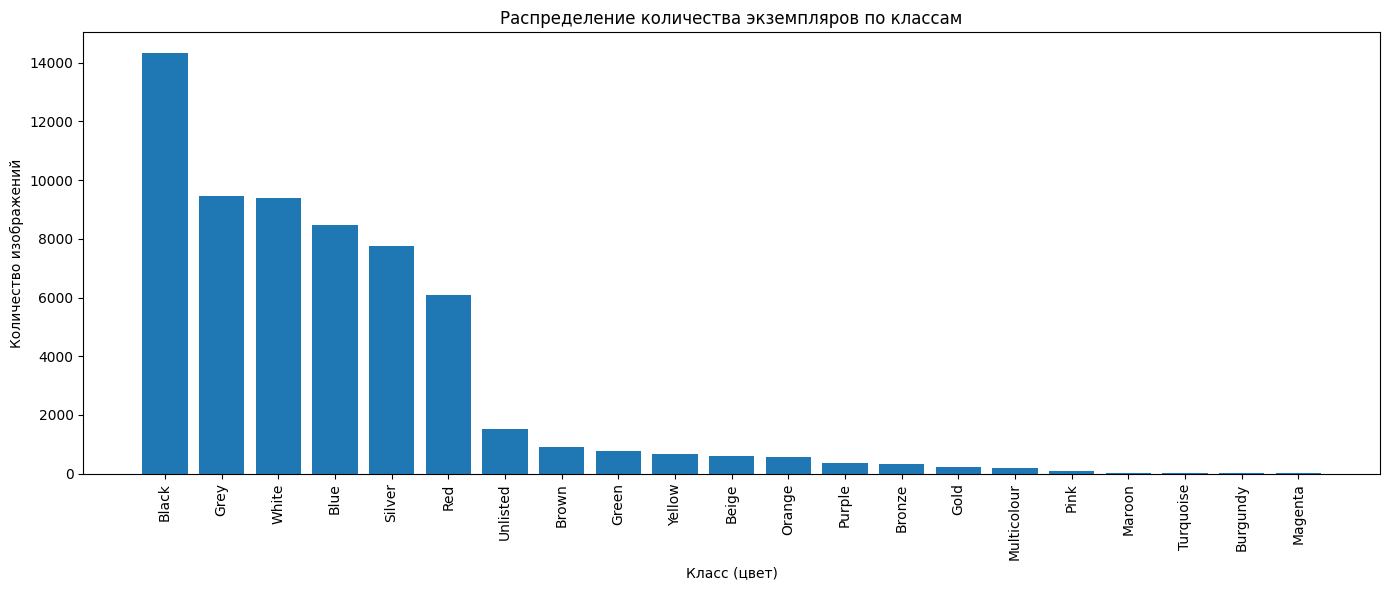

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

cnt = Counter(colors)

items = sorted(cnt.items(), key=lambda x: x[1], reverse=True)
labels = [x[0] for x in items]
values = [x[1] for x in items]

plt.figure(figsize=(14, 6))
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.ylabel("Количество изображений")
plt.xlabel("Класс (цвет)")
plt.title("Распределение количества экземпляров по классам")
plt.tight_layout()
plt.show()

In [ ]:
merge_map = {
    "Silver": "Grey",
    "Maroon": "Red",
    "Burgundy": "Red",
    "Turquoise": "Blue",
    "Pink": "Purple",
    "Gold": "Beige",
    "Bronze": "Brown",
}

rm_classes = {"Unlisted", "Multicolour", "Magenta"}

mask = np.array([c not in rm_classes for c in colors])
my_cars = np.array(my_cars)[mask]
colors = np.array(colors)[mask]

colors = np.array([merge_map.get(c, c) for c in colors])

classes = sorted(set(colors))
class_id = {c: i for i, c in enumerate(classes)}
y = np.array([class_id[c] for c in colors])

print("num classes:", len(classes))
print(classes)

from collections import Counter
print(Counter(colors))

num classes: 11
[np.str_('Beige'), np.str_('Black'), np.str_('Blue'), np.str_('Brown'), np.str_('Green'), np.str_('Grey'), np.str_('Orange'), np.str_('Purple'), np.str_('Red'), np.str_('White'), np.str_('Yellow')]
Counter({np.str_('Grey'): 17244, np.str_('Black'): 14317, np.str_('White'): 9395, np.str_('Blue'): 8509, np.str_('Red'): 6130, np.str_('Brown'): 1240, np.str_('Beige'): 817, np.str_('Green'): 777, np.str_('Yellow'): 667, np.str_('Orange'): 559, np.str_('Purple'): 449})


In [ ]:
classes = sorted(set(colors))
class_id = {c:i for i,c in enumerate(classes)}
y = np.array([class_id[c] for c in colors])

x_train, x_tmp, y_train, y_tmp = train_test_split(my_cars, y, test_size=0.30, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

print("train/val/test:", len(x_train), len(x_val), len(x_test))
print("num classes:", len(classes))

train/val/test: 42072 9016 9016
num classes: 11


In [ ]:
trf_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

trf_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


class Car_ds(Dataset):
  def __init__(self, paths, labels, transform=None):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

  def __len__(self):
        return len(self.paths)

  def __getitem__(self, idx):
        p = self.paths[idx]
        y = int(self.labels[idx])
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, y

In [ ]:
train_ds = Car_ds(x_train, y_train, transform = trf_train)
val_ds = Car_ds(x_val ,y_val ,transform = trf_test)
test_ds = Car_ds(x_test, y_test, transform = trf_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, pin_memory=True)

xb, yb = next(iter(train_loader))
print("batch:", xb.shape, yb.shape)

batch: torch.Size([32, 3, 224, 224]) torch.Size([32])


In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        self.shortcut = nn.Identity()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)

class my_cls_net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )
        self.layer1 = nn.Sequential(BasicBlock(64, 64, 1), BasicBlock(64, 64, 1))
        self.layer2 = nn.Sequential(BasicBlock(64, 128, 2), BasicBlock(128, 128, 1))
        self.layer3 = nn.Sequential(BasicBlock(128, 256, 2), BasicBlock(256, 256, 1))

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

my_model = my_cls_net(num_classes=len(classes)).to(device)

In [ ]:
@torch.no_grad()
def eval_f1(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        log = model(x)
        pred = log.argmax(dim=1).cpu().numpy()
        y_pred.append(pred)
        y_true.append(y.numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    return f1_score(y_true, y_pred, average="macro")


def train_epoch(model, loader, opt, crit):
    model.train()
    total_ls = 0.0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device,non_blocking=True), y.to(device,non_blocking=True)
        opt.zero_grad(set_to_none=True)
        log = model(x)
        ls = crit(log, y)
        ls.backward()
        opt.step()
        total_ls += ls.item()
    return total_ls / max(1, len(loader))


def fit_model(model, epochs=10, lr=3e-4):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()

    best_f1, best_state = -1, None
    for ep in range(1, epochs+1):
        ls = train_epoch(model, train_loader, opt, crit)
        val_f1 = eval_f1(model, val_loader)
        print(f"epoch {ep:02d} | loss={ls:.4f} | val_f1_macro={val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, best_f1

In [ ]:
print("device:", device)
print("model device:", next(my_model.parameters()).device)

x, y = next(iter(train_loader))
print("batch device:", x.device, y.device)

device: cuda
model device: cuda:0
batch device: cpu cpu


In [ ]:
my_model, best_val_f1= fit_model(my_model, epochs=7, lr=3e-4)

epoch 01 | loss=1.0349 | val_f1_macro=0.2260


epoch 02 | loss=0.7919 | val_f1_macro=0.3348


epoch 03 | loss=0.7131 | val_f1_macro=0.3525


epoch 04 | loss=0.6590 | val_f1_macro=0.3644


epoch 05 | loss=0.6148 | val_f1_macro=0.3941


epoch 06 | loss=0.5807 | val_f1_macro=0.3779


epoch 07 | loss=0.5469 | val_f1_macro=0.4050


In [ ]:
test_f1 = eval_f1(my_model, test_loader)
test_f1

0.4032695286319423

Обучение предобученной модели

In [ ]:
def crop_glass(img, top_frac=0.20, bottom_frac=0.08):
    w, h = img.size
    top = int(h * top_frac)
    bottom = int(h * (1 - bottom_frac))
    return img.crop((0, top, w, bottom))

In [ ]:
img_net_mn = [0.485, 0.456, 0.406]
img_net_std = [0.229, 0.224, 0.225]

train_ds.transform = transforms.Compose([
    transforms.Lambda(lambda img: crop_glass(img, top_frac=0.21, bottom_frac=0.32)),
    transforms.Resize(192),
    transforms.CenterCrop(150),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(img_net_mn, img_net_std),
])

val_ds.transform = transforms.Compose([
    transforms.Lambda(lambda img: crop_glass(img, top_frac=0.21, bottom_frac=0.32)),
    transforms.Resize(192),
    transforms.CenterCrop(150),
    transforms.ToTensor(),
    transforms.Normalize(img_net_mn, img_net_std),
])

test_ds.transform = val_ds.transform

In [ ]:
cnt = Counter(y_train)
class_sample_count = np.array([cnt[i] for i in range(len(classes))], dtype=np.float32)
weights_per_class = 1.0 / class_sample_count
sample_weights = np.array([weights_per_class[y] for y in y_train], dtype=np.float32)
weights_per_class = torch.tensor(
    weights_per_class,
    dtype=torch.float32,
    device=device
)

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)


train_pre_loader = DataLoader(train_ds, batch_size=16,sampler=sampler, num_workers=0, pin_memory=True)
val_pre_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_pre_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

In [ ]:
scaler = torch.cuda.amp.GradScaler()

scaler = torch.amp.GradScaler('cuda')

def train_epoch_amp(model, loader, opt, crit):
    model.train()
    total_ls = 0.0

    pbar = tqdm(loader, leave=False)
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            out = model(x)
            ls = crit(out, y)

        scaler.scale(ls).backward()
        scaler.step(opt)
        scaler.update()

        total_ls += ls.item()
        pbar.set_description(f"loss={ls.item():.4f}")

    return total_ls / max(1, len(loader))

/tmp/ipykernel_332/3683217918.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
pre_model = torchvision.models.densenet121(
    weights=torchvision.models.DenseNet121_Weights.IMAGENET1K_V1
)

in_features = pre_model.classifier.in_features

pre_model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Linear(256, len(classes))
)
pre_model = pre_model.to(device)
print(pre_model.classifier)

Sequential(
  (0): Linear(in_features=1024, out_features=256, bias=True)
  (1): ReLU()
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Linear(in_features=256, out_features=11, bias=True)
)


shape: torch.Size([3, 150, 150])
label id: 9
class: White


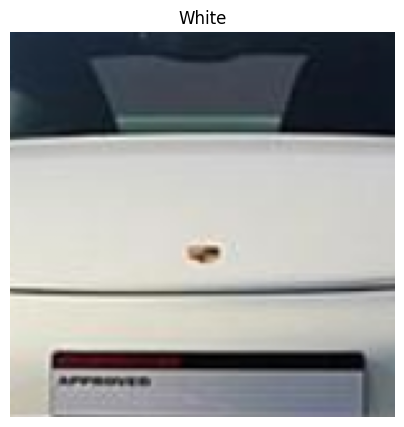

In [ ]:
import matplotlib.pyplot as plt
import torch

img, label = train_ds[24000]

print("shape:", img.shape)
print("label id:", label)
print("class:", classes[label])

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

img_show = img.cpu().clone()
img_show = img_show * std + mean
img_show = img_show.clamp(0, 1)

plt.figure(figsize=(5,5))
plt.imshow(img_show.permute(1, 2, 0))
plt.title(classes[label])
plt.axis("off")
plt.show()

In [ ]:
for p in pre_model.features.parameters():
    p.requires_grad = True

print("features trainable:", any(p.requires_grad for p in pre_model.features.parameters()))

features trainable: True


In [ ]:
params = list(pre_model.features.parameters()) + list(pre_model.classifier.parameters())
opt = torch.optim.AdamW(params, lr=5e-5, weight_decay=1e-4)
crit = nn.CrossEntropyLoss(label_smoothing=0.05)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="max",
    factor=0.5,
    patience=1
)

In [ ]:
best_f1 = 0
best_state = None

for ep in range(1, 10):
    ls = train_epoch_amp(pre_model, train_pre_loader, opt, crit)
    val_f1 = eval_f1(pre_model, val_pre_loader)
    print(f"[Dense-full] epoch {ep:02d} | loss={ls:.4f} | val_f1_macro={val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in pre_model.state_dict().items()}

    scheduler.step(val_f1)

[Dense-full] epoch 01 | loss=1.0325 | val_f1_macro=0.6577


[Dense-full] epoch 02 | loss=0.6294 | val_f1_macro=0.7201


[Dense-full] epoch 03 | loss=0.5381 | val_f1_macro=0.7406


[Dense-full] epoch 04 | loss=0.4932 | val_f1_macro=0.7654


[Dense-full] epoch 05 | loss=0.4655 | val_f1_macro=0.7649


[Dense-full] epoch 06 | loss=0.4447 | val_f1_macro=0.7764


[Dense-full] epoch 07 | loss=0.4317 | val_f1_macro=0.7684


[Dense-full] epoch 08 | loss=0.4180 | val_f1_macro=0.7870


[Dense-full] epoch 09 | loss=0.4046 | val_f1_macro=0.7865


Вывод: transfer learning оказался значительно эффективнее обучения с нуля, однако требуемый порог качества F1_macro > 0.8 в текущем варианте достигнут не был